# Telecom Churn Prediction
**Author:** Suddhasish kar

The goal of this notebook is to provide an overview of how write a notebook and create a submission file that successfully solves the churn prediction problem. Please download the datasets, unzip and place them in the same folder as this notebook.

We are going to follow the process called CRISP-DM.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b9/CRISP-DM_Process_Diagram.png/639px-CRISP-DM_Process_Diagram.png" style="height: 400px; width:400px;"/>

After Business and Data Understanding via EDA, we want to prepare data for modelling. Then evaluate and submit our predictions.

# 0. Problem statement

In the telecom industry, customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.

For many incumbent operators, retaining high profitable customers is the number one business
goal. To reduce customer churn, telecom companies need to predict which customers are at high risk of churn. In this project, you will analyze customer-level data of a leading telecom firm, build predictive models to identify customers at high risk of churn, and identify the main indicators of churn.

In this competition, your goal is *to build a machine learning model that is able to predict churning customers based on the features provided for their usage.*

**Customer behaviour during churn:**

Customers usually do not decide to switch to another competitor instantly, but rather over a
period of time (this is especially applicable to high-value customers). In churn prediction, we
assume that there are three phases of customer lifecycle :

1. <u>The ‘good’ phase:</u> In this phase, the customer is happy with the service and behaves as usual.

2. <u>The ‘action’ phase:</u> The customer experience starts to sore in this phase, for e.g. he/she gets a compelling offer from a competitor, faces unjust charges, becomes unhappy with service quality etc. In this phase, the customer usually shows different behaviour than the ‘good’ months. It is crucial to identify high-churn-risk customers in this phase, since some corrective actions can be taken at this point (such as matching the competitor’s offer/improving the service quality etc.)

3. <u>The ‘churn’ phase:</u> In this phase, the customer is said to have churned. In this case, since you are working over a four-month window, the first two months are the ‘good’ phase, the third month is the ‘action’ phase, while the fourth month (September) is the ‘churn’ phase.

# 1. Loading dependencies & datasets

Lets start by loading our dependencies. We can keep adding any imports to this cell block, as we write mode and mode code.

In [57]:
#Data Structures
import pandas as pd
import numpy as np
import re
import os

### For installing missingno library, type this command in terminal
#pip install missingno

import missingno as msno

#Sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score

#Plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

#Others
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Next, we load our datasets and the data dictionary file.

The **train.csv** file contains both dependent and independent features, while the **test.csv** contains only the independent variables. 

So, for model selection, I will create our own train/test dataset from the **train.csv** and use the model to predict the solution using the features in unseen test.csv data for submission.

In [58]:
#INCASE RUNNING THIS LOCALLY, PASS THE RELATIVE PATH OF THE CSV FILES BELOW
#(e.g. if files are in same folder as notebook, simple write "train.csv" as path)

data = pd.read_csv("train.csv")
unseen = pd.read_csv("test.csv")
sample = pd.read_csv("sample.csv")
data_dict = pd.read_csv("data_dictionary.csv")

print(data.shape)
print(unseen.shape)
print(sample.shape)
print(data_dict.shape)

(69999, 172)
(30000, 171)
(30000, 2)
(36, 2)


1. Lets analyze the data dictionary versus the churn dataset.
2. The data dictonary contains a list of abbrevations which provide you all the information you need to understand what a specific feature/variable in the churn dataset represents
3. Example: 

> "arpu_7" -> Average revenue per user + KPI for the month of July
>
> "onnet_mou_6" ->  All kind of calls within the same operator network + Minutes of usage voice calls + KPI for the month of June
>
>"night_pck_user_8" -> Scheme to use during specific night hours only + Prepaid service schemes called PACKS + KPI for the month of August
>
>"max_rech_data_7" -> Maximum + Recharge + Mobile internet + KPI for the month of July

Its important to understand the definitions of each feature that you are working with, take notes on which feature you think might impact the churn rate of a user, and what sort of analysis could you do to understand the distribution of the feature better.

In [59]:
data_dict

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


For the purpose of this **starter notebook**, we I will restrict the dataset to only a small set of variables. 

The approach I use here is to understand each Acronym, figure our what variable might be important and filter out variable names based on the combinations of acrynoms using REGEX. So, if I want the total minutes a person has spent on outgoing calls, I need acronyms, TOTAL, OG and MOU. So corresponding regex is ```total.+og.+mou```

In [60]:
data.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,7.527,48.58,124.38,1.29,32.24,96.68,2.33,0.00,0.0,0.0,0.00,0.0,0.00,2.23,0.00,0.28,5.29,16.04,2.33,0.00,0.00,0.00,0.00,0.00,0.00,7.53,16.04,2.61,46.34,124.38,1.01,18.75,80.61,0.0,0.00,0.0,0.0,0.0,0.0,0.0,65.09,204.99,1.01,0.0,0.0,0.0,8.20,0.63,0.00,0.38,0.0,0.0,81.21,221.68,3.63,2.43,3.68,7.79,0.83,21.08,16.91,0.00,0.00,0.00,3.26,24.76,24.71,0.00,7.61,0.21,7.46,19.96,14.96,0.0,0.0,0.0,0.0,0.0,0.0,7.46,27.58,15.18,11.84,53.04,40.56,0.0,0.0,0.66,0.0,0.0,0.0,1.11,0.69,0.00,3,2,2,77,65,10,65,65,10,6/22/2014,7/10/2014,8/24/2014,65,65,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0.00,0.0,0.00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,42.953,0.00,0.00,0.00,0.00,25.99,30.89,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,22.01,29.79,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,30.73,31.66,0.00,0.0,0.0,0.00,30.73,31.66,1.68,19.09,10.53,1.41,18.68,11.09,0.35,1.66,3.40,3.44,39.44,25.03,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,3.44,39.44,25.04,0.0,0.0,0.01,0.0,0.0,0.0,0.00,0.00,0.00,3,4,5,0,145,50,0,145,50,6/12/2014,7/10/2014,8/26/2014,0,0,0,NaN,7/8/2014,NaN,NaN,1.0,NaN,NaN,145.0,NaN,NaN,0.0,NaN,NaN,1.0,NaN,Na

In [61]:
data.shape

(69999, 172)

Let's look at each variable's datatype:

In [62]:
data.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    id                        int64  
 1    circle_id                 int64  
 2    loc_og_t2o_mou            float64
 3    std_og_t2o_mou            float64
 4    loc_ic_t2o_mou            float64
 5    last_date_of_month_6      object 
 6    last_date_of_month_7      object 
 7    last_date_of_month_8      object 
 8    arpu_6                    float64
 9    arpu_7                    float64
 10   arpu_8                    float64
 11   onnet_mou_6               float64
 12   onnet_mou_7               float64
 13   onnet_mou_8               float64
 14   offnet_mou_6              float64
 15   offnet_mou_7              float64
 16   offnet_mou_8              float64
 17   roam_ic_mou_6             float64
 18   roam_ic_mou_7             float64
 19   roam_ic_mou_8             float64
 20   roam

In [63]:
pd.DataFrame(data.columns)

,0
0,id
1,circle_id
2,loc_og_t2o_mou
3,std_og_t2o_mou
4,loc_ic_t2o_mou
5,last_date_of_month_6
6,last_date_of_month_7
7,last_date_of_month_8
8,arpu_6
9,arpu_7


Let's also summarize the features using the df.describe method:

In [64]:
data.describe(include="all")

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
count,69999.000000,69999.0,69297.0,69297.0,69297.0,69999,69600,69266,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.0,67312.0,66296.0,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.0,67312.0,66296.0,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,67231.000000,67312.000000,66296.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,68898,68765,67538,69999.000000,69999.000000

# 2. Create X, y and then Train test split

Lets create X and y datasets and skip "circle_id" since it has only 1 unique value

In [65]:
X = data.drop(columns=['churn_probability'])
y = data['churn_probability']

X.shape, y.shape

((69999, 171), (69999,))

Splitting train and test data to avoid any contamination of the test data

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((55999, 171), (14000, 171), (55999,), (14000,))

In [67]:
X_train.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
47338,47338,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,172.250,149.720,244.222,20.71,13.16,48.34,152.38,129.73,268.23,0.0,0.0,0.0,0.0,0.0,0.0,20.71,13.16,48.34,140.83,121.26,241.23,11.54,6.79,26.99,0.00,1.66,0.0,173.09,141.23,316.58,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,1.66,0.00,0.00,0.0,0.0,173.09,142.89,316.58,17.83,16.69,34.51,44.74,29.91,82.41,6.89,40.14,79.53,69.48,86.76,196.46,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.00,166.04,121.78,205.19,0.0,0.0,0.0,96.56,35.01,8.73,0.00,0.00,0.0,6,4,2,0,0,398,0,0,398,6/27/2014,7/25/2014,8/6/2014,0,0,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,395,0.0,0.0,0.0
67455,67455,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,155.610,53.934,47.532,11.84,7.54,5.33,107.69,44.76,28.31,0.0,0.0,0.0,0.0,0.0,0.0,11.84,7.54,5.33,86.66,31.26,28.31,0.00,0.00,0.00,20.63,0.00,0.0,98.51,38.81,33.64,0.00,0.00,0.00,0.00,11.13,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,11.13,0.00,0.0,0.0,0.0,21.26,2.88,2.18,0.00,0.0,0.0,119.78,52.83,35.83,109.71,77.11,15.64,533.33,288.61,204.88,2.00,0.55,0.00,645.04,366.28,220.53,0.00,0.00,0.00,0.00,32.41,0.00,0.0,0.73,0.0,0.0,0.0,0.0,0.00,33.14,0.00,645.04,399.43,220.53,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,12,4,3,174,57,70,30,30,30,6/30/2014,7/21/2014,8/28/2014,10,7,30,NaN,NaN,NaN,NaN,NaN,NaN,

# 3. Handling Missing data

First lets analyse the missing data. We can use missingno library for quick visualizations.

<Axes: >

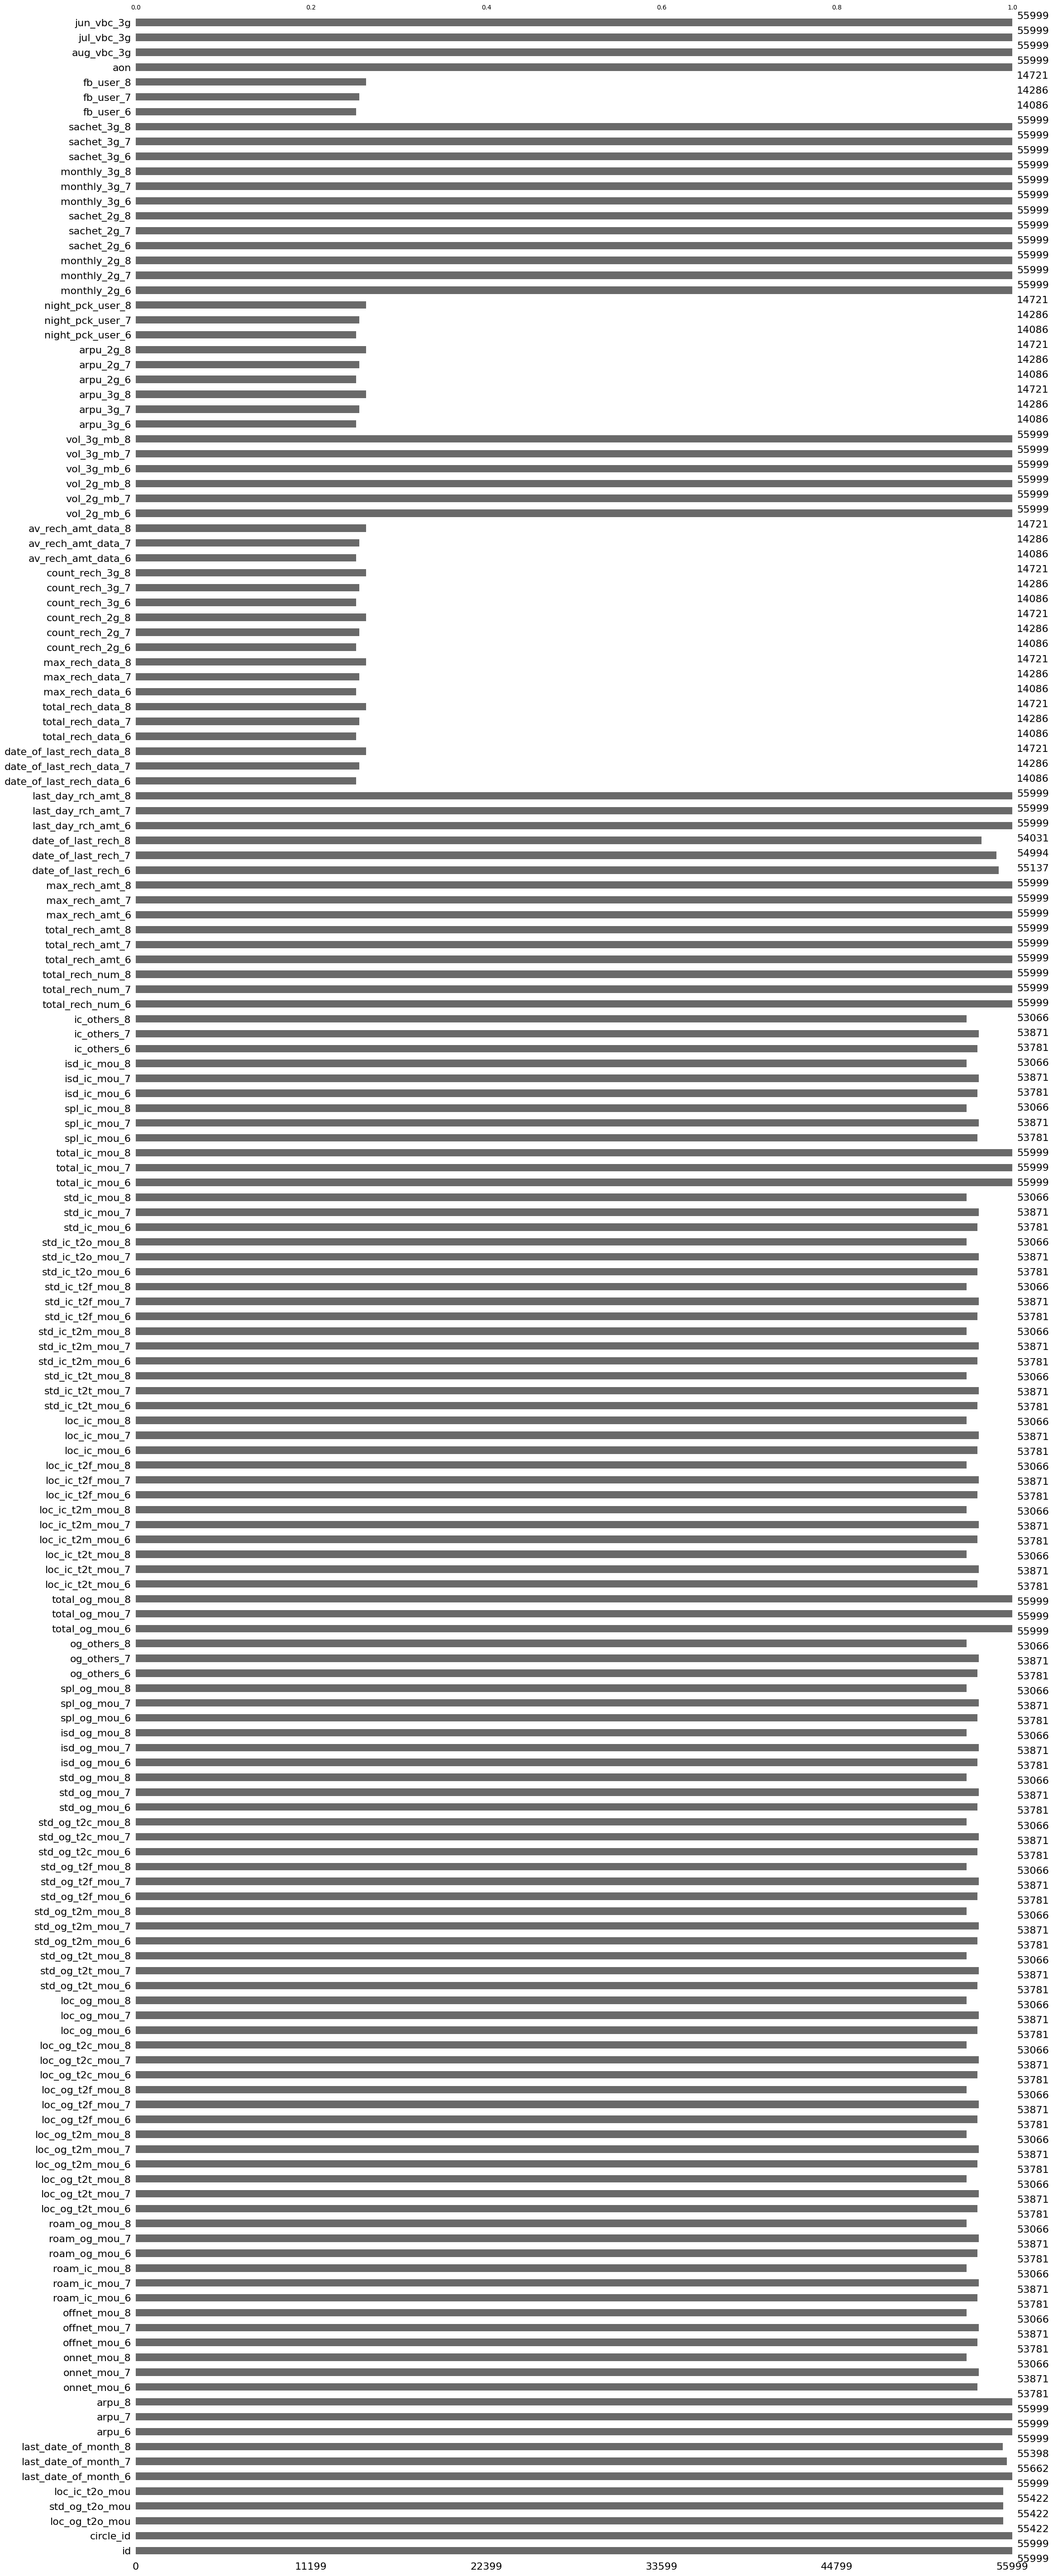

In [68]:
msno.bar(X_train)

In [69]:
pd.set_option('display.max_rows', 180)
pd.set_option('display.max_columns', 180)

Lets also calculate the % missing data for each column:

In [70]:
missing_data_percent = 100*X_train.isnull().sum()/len(y_train)
missing_data_percent.sort_values()

id                           0.000000
circle_id                    0.000000
last_date_of_month_6         0.000000
arpu_6                       0.000000
arpu_7                       0.000000
arpu_8                       0.000000
total_og_mou_7               0.000000
total_og_mou_6               0.000000
last_day_rch_amt_6           0.000000
last_day_rch_amt_7           0.000000
last_day_rch_amt_8           0.000000
max_rech_amt_8               0.000000
total_ic_mou_8               0.000000
total_ic_mou_6               0.000000
total_ic_mou_7               0.000000
total_og_mou_8               0.000000
max_rech_amt_7               0.000000
max_rech_amt_6               0.000000
total_rech_amt_8             0.000000
total_rech_amt_7             0.000000
total_rech_amt_6             0.000000
total_rech_num_8             0.000000
total_rech_num_7             0.000000
total_rech_num_6             0.000000
monthly_3g_7                 0.000000
monthly_3g_6                 0.000000
vol_2g_mb_6 

Since too much missing information would make a column not really a great predictor for churn, we drop these columns and keep only the ones which have less than 50% missing data.

In [71]:
new_vars = missing_data_percent[missing_data_percent.le(50)].index
new_vars

Index(['id', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
       'arpu_6', 'arpu_7',
       ...
       'monthly_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'sachet_3g_6',
       'sachet_3g_7', 'sachet_3g_8', 'aon', 'aug_vbc_3g', 'jul_vbc_3g',
       'jun_vbc_3g'],
      dtype='object', length=141)

In [72]:
X_train_filtered = X_train[new_vars]
X_train_filtered.shape

(55999, 141)

Next, we try imputation on variables with any amount of missing data still left. There are multiple ways of imputing data, and each will require a good business understanding of what the missing data is and how you may handle it.

Some tips while working with missing data - 

1. Can simply replace missing values directly with a constant value such as 0
2. In certain cases you may want to replace it with the average value for each column respectively
3. For timeseries data, you may consider using linear or spline interplolation between a set of points, if you have data available for some of the months, and missing for the others.
4. You can consider more advance methods for imputation such as MICE.

In our case, I will just demostrate a simple imputation with constant values as zeros.

In [73]:
missing_data_percent = X_train_filtered.isnull().any()
impute_cols = missing_data_percent[missing_data_percent.gt(0)].index
impute_cols

Index(['loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_7', 'last_date_of_month_8', 'onnet_mou_6',
       'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7',
       'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8',
       'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_t2t_mou_6',
       'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 'loc_og_t2m_mou_6',
       'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8', 'loc_og_t2f_mou_6',
       'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8', 'loc_og_t2c_mou_6',
       'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8', 'loc_og_mou_6', 'loc_og_mou_7',
       'loc_og_mou_8', 'std_og_t2t_mou_6', 'std_og_t2t_mou_7',
       'std_og_t2t_mou_8', 'std_og_t2m_mou_6', 'std_og_t2m_mou_7',
       'std_og_t2m_mou_8', 'std_og_t2f_mou_6', 'std_og_t2f_mou_7',
       'std_og_t2f_mou_8', 'std_og_t2c_mou_6', 'std_og_t2c_mou_7',
       'std_og_t2c_mou_8', 'std_og_mou_6', 'std_og_mou_7', 'std_og_mou_8',
       'isd_og_mou_6', 'isd_o

In [74]:
X_train_filtered[impute_cols].describe()

,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8
count,55422.0,55422.0,55422.0,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.0,53871.0,53066.0,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.0,53871.0,53066.0,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000,53781.000000,53871.000000,53066.000000
mean,0.0,0.0,0.0,132.633026,134.060154,133.102209,199.452119,198.079485,196.196893,9.732983,7.036236,6.861002,14.326272,9.876271,9.744147,46.279170,45.741807,45.368193,93.447994,91.248339,91.015265,3.757654,3.775502,3.664084,1.135470,1.362516,1.421303,143.492124,140.772996,140.054831,80.679762,84.388000,83.975566,88.441550,91.999527,90.365407,1.120044,1.077720,1.044912,0.0,0.0,0.0,170.244088,177.467943,175.388526,0.803150,0.745823,0.775960,3.977655,5.021303,5.075688,0.471620,0.026977,0.036512,48.203794,47.878287,47.549855,107.231622,106.913931,108.107166,12.079676,12.619841,11.775138,167.523858,167.420924,167.441025,9.597388,10.078188,10.090224,20.706946,21.863334,21.183834,2.113729,2.209086,2.043191,0.0,0.0,0.0,32.420616,34.153212,33.319850,0.062546,0.033411,0.040493,7.359849,8.231941,8.242653,0.812463,0.977758,0.954504
std,0.0,0.0,0.0,298.129491,311.968639,314.319545,319.540963,324.322725,320.878139,55.516017,56.783386,50.561394,75.442174,59.195849,64.173817,147.592837,151.963510,154.799495,163.843292,155.554150,153.032532,13.353578,13.748903,13.086238,5.684102,8.238439,6.579122,251.564732,245.964091,246.407411,254.386870,268.982424,269.598152,258.069157,268.936094,266.365954,8.040941,8.055651,7.498304,0.0,0.0,0.0,392.709166,411.667951,409.749858,28.867259,26.199543,27.428125,15.917898,23.169530,17.853189,5.263279,1.899739,2.447939,142.551438,147.249864,144.193238,170.323119,168.069876,166.345958,39.428300,43.879775,38.674953,255.386416,256.630114,251.663137,53.061885,59.138200,54.455373,

In [75]:
imp = SimpleImputer(strategy='constant', fill_value=0)
X_train_filtered[impute_cols] = imp.fit_transform(X_train_filtered[impute_cols])
X_test[impute_cols] = imp.fit_transform(X_test[impute_cols])
unseen[impute_cols] = imp.fit_transform(unseen[impute_cols])

In [76]:
impute_cols

Index(['loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_7', 'last_date_of_month_8', 'onnet_mou_6',
       'onnet_mou_7', 'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7',
       'offnet_mou_8', 'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8',
       'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_t2t_mou_6',
       'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 'loc_og_t2m_mou_6',
       'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8', 'loc_og_t2f_mou_6',
       'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8', 'loc_og_t2c_mou_6',
       'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8', 'loc_og_mou_6', 'loc_og_mou_7',
       'loc_og_mou_8', 'std_og_t2t_mou_6', 'std_og_t2t_mou_7',
       'std_og_t2t_mou_8', 'std_og_t2m_mou_6', 'std_og_t2m_mou_7',
       'std_og_t2m_mou_8', 'std_og_t2f_mou_6', 'std_og_t2f_mou_7',
       'std_og_t2f_mou_8', 'std_og_t2c_mou_6', 'std_og_t2c_mou_7',
       'std_og_t2c_mou_8', 'std_og_mou_6', 'std_og_mou_7', 'std_og_mou_8',
       'isd_og_mou_6', 'isd_o

## 3.1 Removing Feature the one unique Value records

In [77]:
for col in list(X_train_filtered.columns):
    print(col, ': ' , X_train_filtered[col].nunique())

id :  55999
circle_id :  1
loc_og_t2o_mou :  1
std_og_t2o_mou :  1
loc_ic_t2o_mou :  1
last_date_of_month_6 :  1
last_date_of_month_7 :  2
last_date_of_month_8 :  2
arpu_6 :  49977
arpu_7 :  49857
arpu_8 :  48837
onnet_mou_6 :  17702
onnet_mou_7 :  17709
onnet_mou_8 :  17383
offnet_mou_6 :  23384
offnet_mou_7 :  23333
offnet_mou_8 :  23110
roam_ic_mou_6 :  4641
roam_ic_mou_7 :  3702
roam_ic_mou_8 :  3696
roam_og_mou_6 :  5687
roam_og_mou_7 :  4592
roam_og_mou_8 :  4504
loc_og_t2t_mou_6 :  10331
loc_og_t2t_mou_7 :  10191
loc_og_t2t_mou_8 :  10144
loc_og_t2m_mou_6 :  16167
loc_og_t2m_mou_7 :  15989
loc_og_t2m_mou_8 :  15849
loc_og_t2f_mou_6 :  3085
loc_og_t2f_mou_7 :  3070
loc_og_t2f_mou_8 :  3035
loc_og_t2c_mou_6 :  1807
loc_og_t2c_mou_7 :  1926
loc_og_t2c_mou_8 :  2024
loc_og_mou_6 :  19919
loc_og_mou_7 :  19715
loc_og_mou_8 :  19607
std_og_t2t_mou_6 :  12563
std_og_t2t_mou_7 :  12701
std_og_t2t_mou_8 :  12423
std_og_t2m_mou_6 :  13960
std_og_t2m_mou_7 :  14182
std_og_t2m_mou_8 :  1389

In [78]:
# Dropping columns with non-unique values
columns_to_drop = ['circle_id', 'last_date_of_month_6','last_date_of_month_7','last_date_of_month_8']

X_train_filtered.drop(columns=columns_to_drop, inplace=True,axis=0)

In [79]:
""" # Dropping Date columns as they do not contribute to business sense
date_columns = ['date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']

X_train_filtered.drop(columns=date_columns, inplace=True)
    
X_train_filtered.head() """

# Convert object columns to datetime and extract the day
date_columns = X_train.select_dtypes(include=['object']).columns
for col in date_columns:
    X_train[col] = pd.to_datetime(X_train_filtered[col], errors='ignore', format='%m/%d/%Y').dt.day
    X_test[col] = pd.to_datetime(X_test[col], errors='ignore', format='%m/%d/%Y').dt.day
    unseen[col] = pd.to_datetime(unseen[col], errors='ignore', format='%m/%d/%Y').dt.day

KeyError: 'last_date_of_month_6'

In [ ]:
X_train_filtered.shape

(55999, 125)

### 3.2 Dropping Columns that are corelated to others

In [ ]:
corr = X_train_filtered.corr()
corr.loc[:, :] = np.tril(corr, -1)
corr = corr.stack()

In [ ]:
corr[(corr > 0.70) | (corr < -0.70)]

arpu_7            arpu_6              0.754668
arpu_8            arpu_7              0.789375
onnet_mou_7       onnet_mou_6         0.734021
onnet_mou_8       onnet_mou_7         0.790770
offnet_mou_7      offnet_mou_6        0.742453
offnet_mou_8      offnet_mou_7        0.761221
loc_og_t2t_mou_7  loc_og_t2t_mou_6    0.796144
loc_og_t2t_mou_8  loc_og_t2t_mou_6    0.706451
                  loc_og_t2t_mou_7    0.811738
loc_og_t2m_mou_7  loc_og_t2m_mou_6    0.791874
loc_og_t2m_mou_8  loc_og_t2m_mou_7    0.813775
loc_og_t2f_mou_7  loc_og_t2f_mou_6    0.776361
loc_og_t2f_mou_8  loc_og_t2f_mou_6    0.713686
                  loc_og_t2f_mou_7    0.782645
loc_og_mou_6      loc_og_t2t_mou_6    0.775074
                  loc_og_t2m_mou_6    0.817367
loc_og_mou_7      loc_og_t2t_mou_7    0.787238
                  loc_og_t2m_mou_7    0.789274
                  loc_og_mou_6        0.814357
loc_og_mou_8      loc_og_t2t_mou_8    0.788939
                  loc_og_t2m_mou_8    0.789966
             

In [ ]:
# Based on the above correlations the following features are well implied by the other features and hence, are less important
columns_to_drop = [
    'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8', 
    'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8',
    'loc_og_t2f_mou_6', 'loc_og_t2f_mou_7', 'loc_og_t2f_mou_8',
    'loc_og_t2c_mou_6', 'loc_og_t2c_mou_7', 'loc_og_t2c_mou_8',
    'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7', 'loc_ic_t2t_mou_8', 
    'loc_ic_t2m_mou_6', 'loc_ic_t2m_mou_7', 'loc_ic_t2m_mou_8',
    'loc_ic_t2f_mou_6', 'loc_ic_t2f_mou_7', 'loc_ic_t2f_mou_8',
    'std_og_t2t_mou_6', 'std_og_t2t_mou_7', 'std_og_t2t_mou_8',
    'std_og_t2m_mou_6', 'std_og_t2m_mou_7', 'std_og_t2m_mou_8',
    'std_og_t2f_mou_6', 'std_og_t2f_mou_7', 'std_og_t2f_mou_8',
    'std_ic_t2t_mou_6', 'std_ic_t2t_mou_7', 'std_ic_t2t_mou_8',
    'std_ic_t2m_mou_6', 'std_ic_t2m_mou_7', 'std_ic_t2m_mou_8',
    'std_ic_t2f_mou_6', 'std_ic_t2f_mou_7', 'std_ic_t2f_mou_8',
]

In [ ]:
X_train_filtered.drop(columns_to_drop, axis=1, inplace=True)
X_train_filtered.shape

(55999, 86)

In [ ]:
X_train_filtered.columns

Index(['id', 'arpu_6', 'arpu_7', 'arpu_8', 'onnet_mou_6', 'onnet_mou_7',
       'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8',
       'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8', 'roam_og_mou_6',
       'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_mou_6', 'loc_og_mou_7',
       'loc_og_mou_8', 'std_og_mou_6', 'std_og_mou_7', 'std_og_mou_8',
       'isd_og_mou_6', 'isd_og_mou_7', 'isd_og_mou_8', 'spl_og_mou_6',
       'spl_og_mou_7', 'spl_og_mou_8', 'og_others_6', 'og_others_7',
       'og_others_8', 'total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8',
       'loc_ic_mou_6', 'loc_ic_mou_7', 'loc_ic_mou_8', 'std_ic_mou_6',
       'std_ic_mou_7', 'std_ic_mou_8', 'total_ic_mou_6', 'total_ic_mou_7',
       'total_ic_mou_8', 'spl_ic_mou_6', 'spl_ic_mou_7', 'spl_ic_mou_8',
       'isd_ic_mou_6', 'isd_ic_mou_7', 'isd_ic_mou_8', 'ic_others_6',
       'ic_others_7', 'ic_others_8', 'total_rech_num_6', 'total_rech_num_7',
       'total_rech_num_8', 'total_rech_amt_6', 'total_re

# 4. Exploratory Data Analysis & Preprocessing

Lets start by analysing the univariate distributions of each feature.

<Axes: >

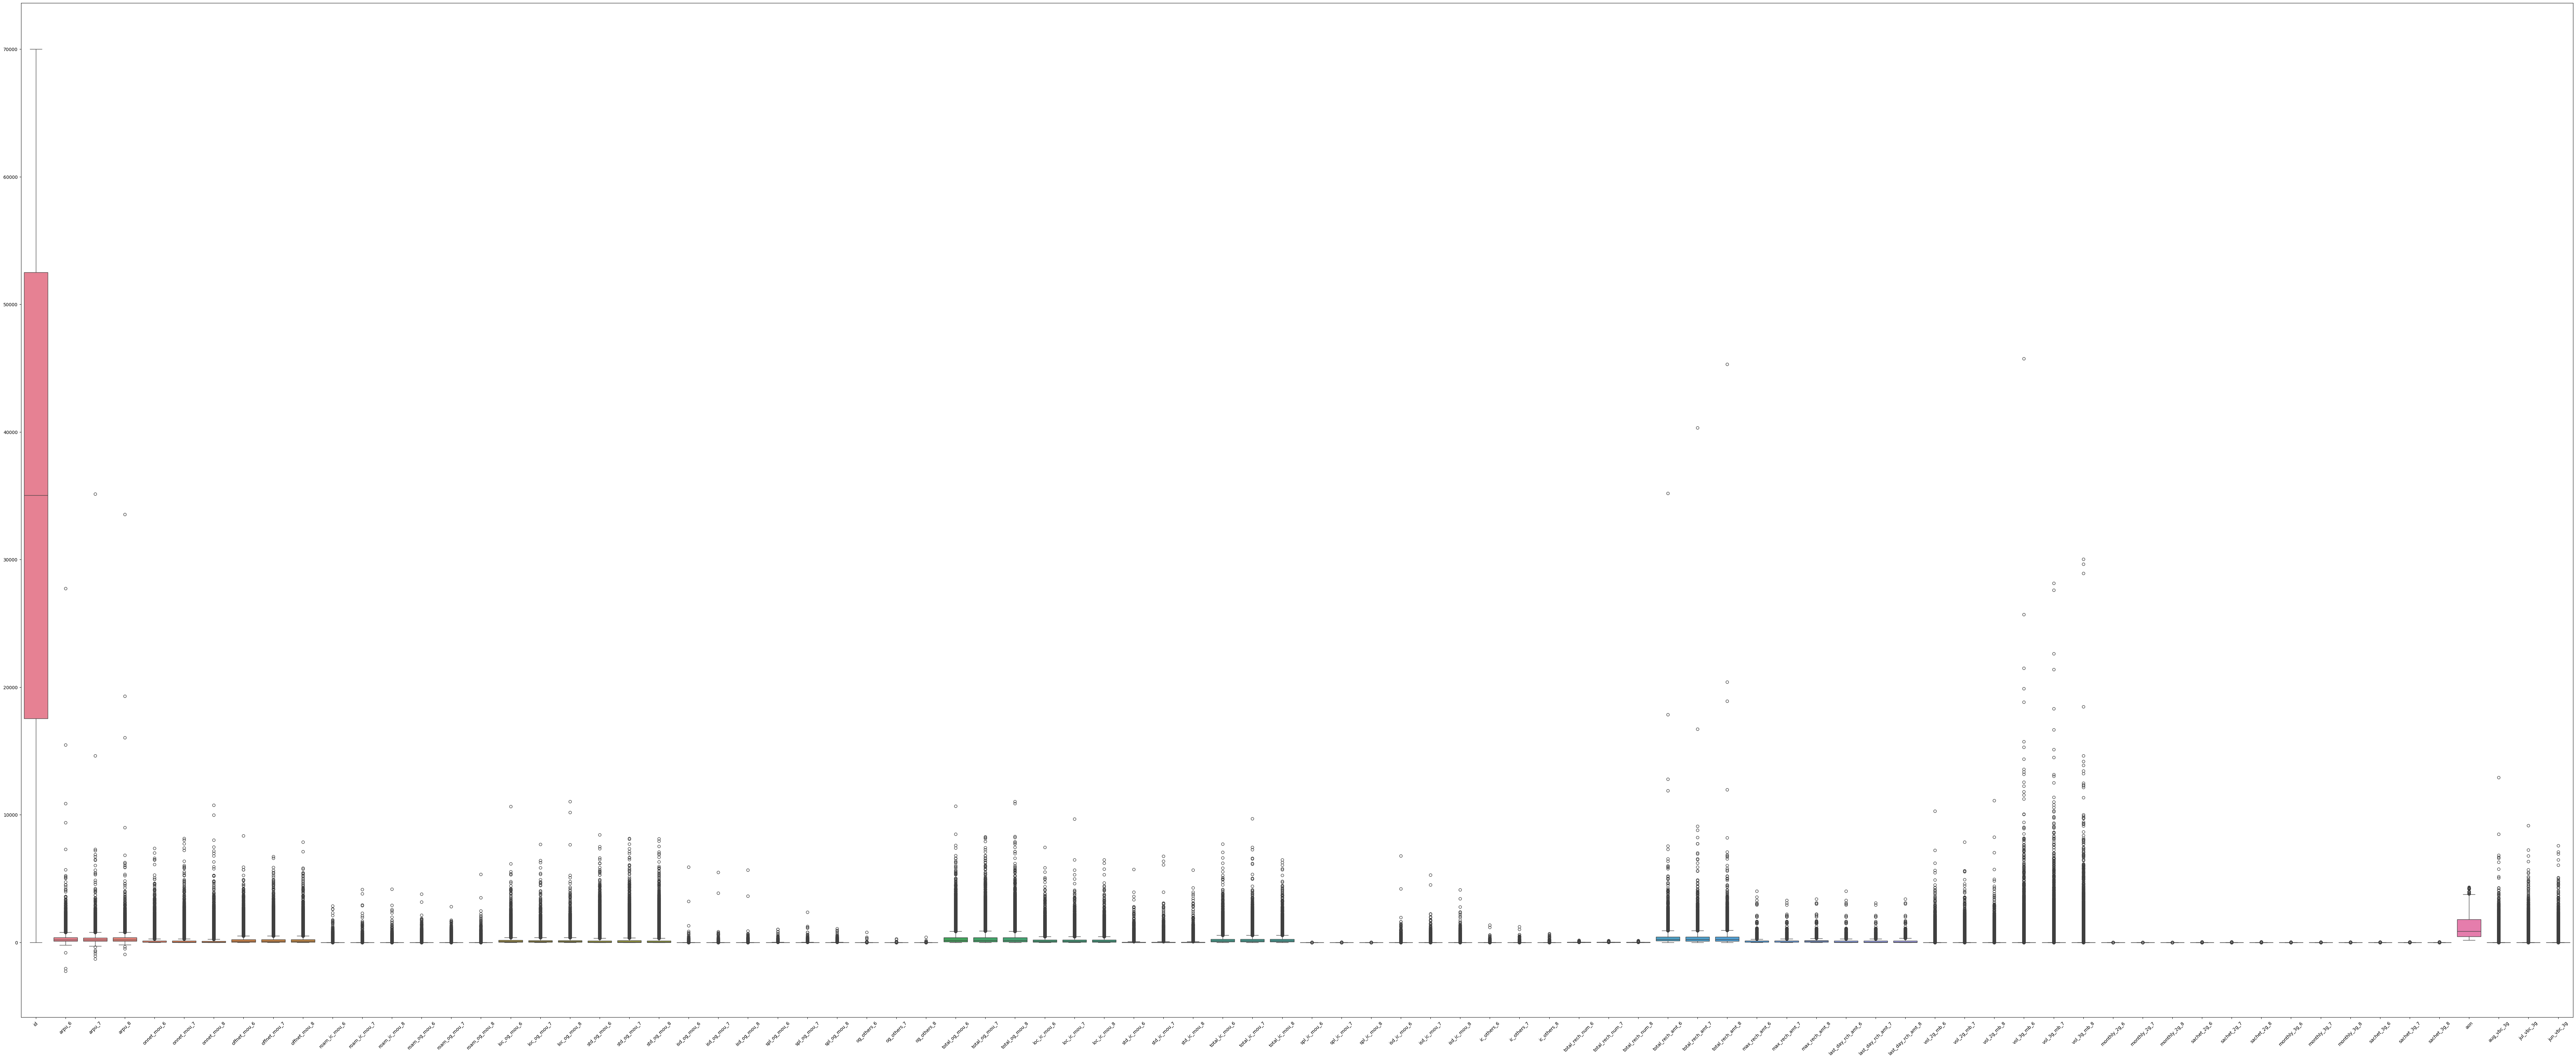

In [ ]:
plt.figure(figsize=(100,40))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered)

### 4.1 Handling outliers

The box plots of these features show there a lot of outliers. These can be capped with k-sigma method.

In [ ]:
def cap_outliers(array, k=3):
    upper_limit = array.mean() + k*array.std()
    lower_limit = array.mean() - k*array.std()
    array[array<lower_limit] = lower_limit
    array[array>upper_limit] = upper_limit
    return array

<Axes: >

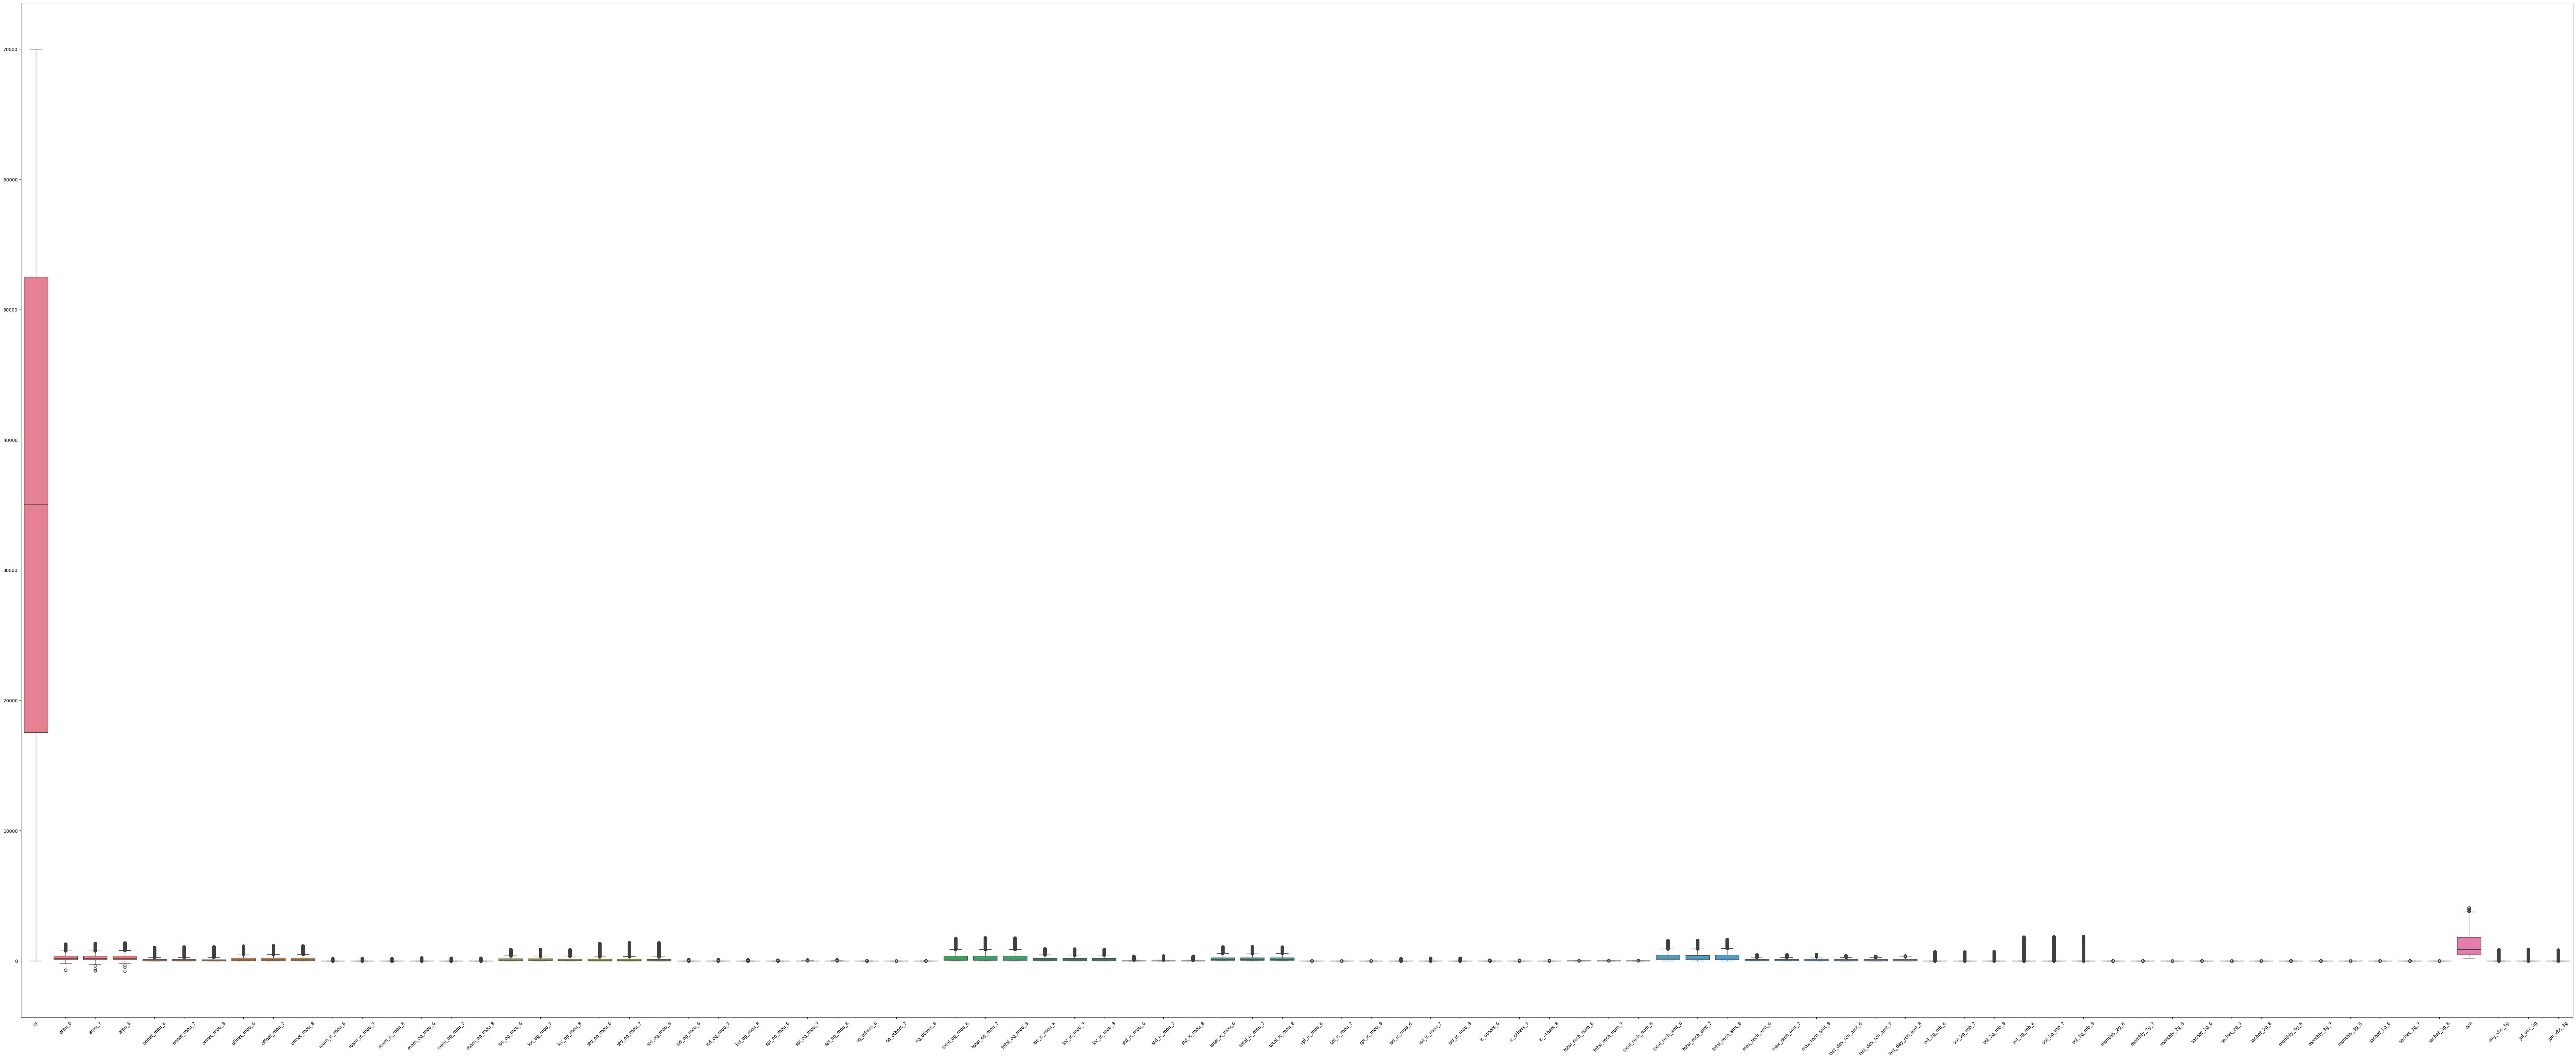

In [ ]:
X_train_filtered1 = X_train_filtered.apply(cap_outliers, axis=0)

plt.figure(figsize=(100,40))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered1)

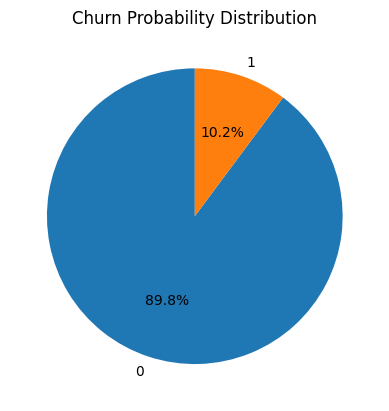

In [ ]:
# Checking Balance of Target Variable
pd.Series(y_train).value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Churn Probability Distribution')
plt.show()

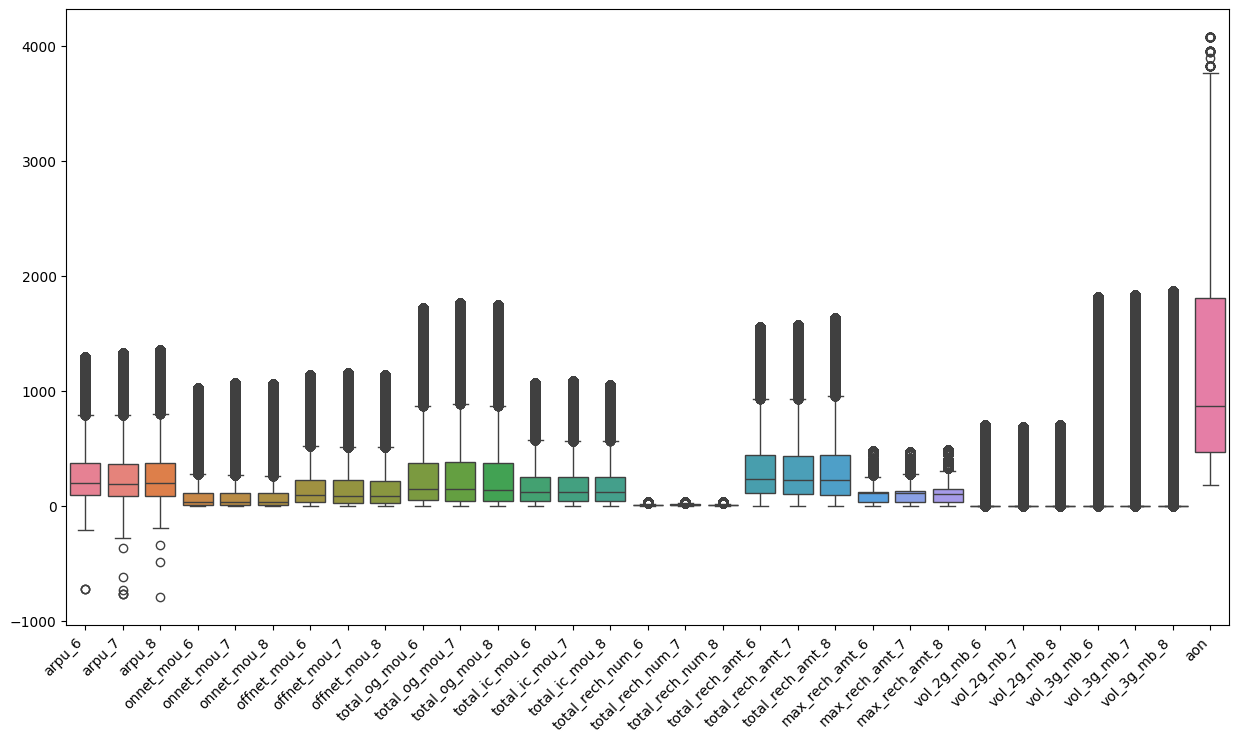

In [ ]:
# Total Usage Metrics
columns = [i for i in list(X_train_filtered1.columns) if re.search('arpu|offnet|onnet|total|max|vol|aon',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train_filtered1[columns])
plt.show()

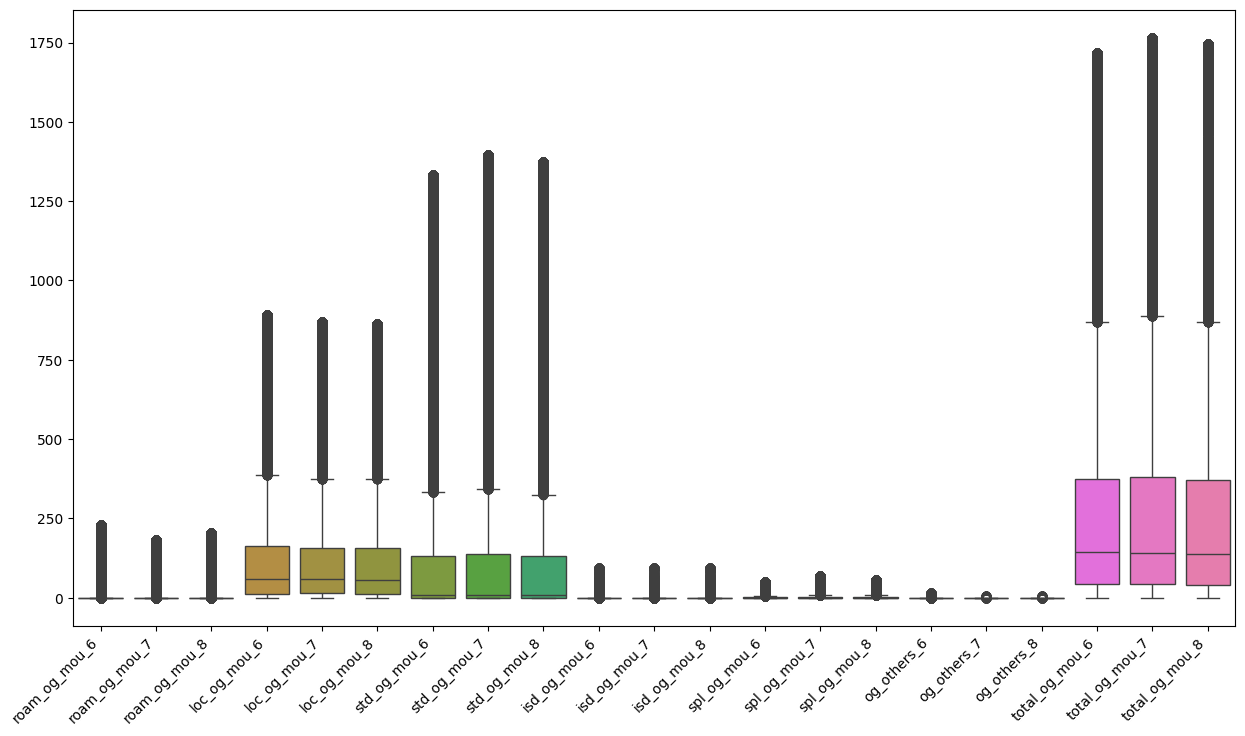

In [ ]:
# Outgoing Usage Metrics
columns = [i for i in list(X_train_filtered1.columns) if re.search('og',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train_filtered1[columns])
plt.show()

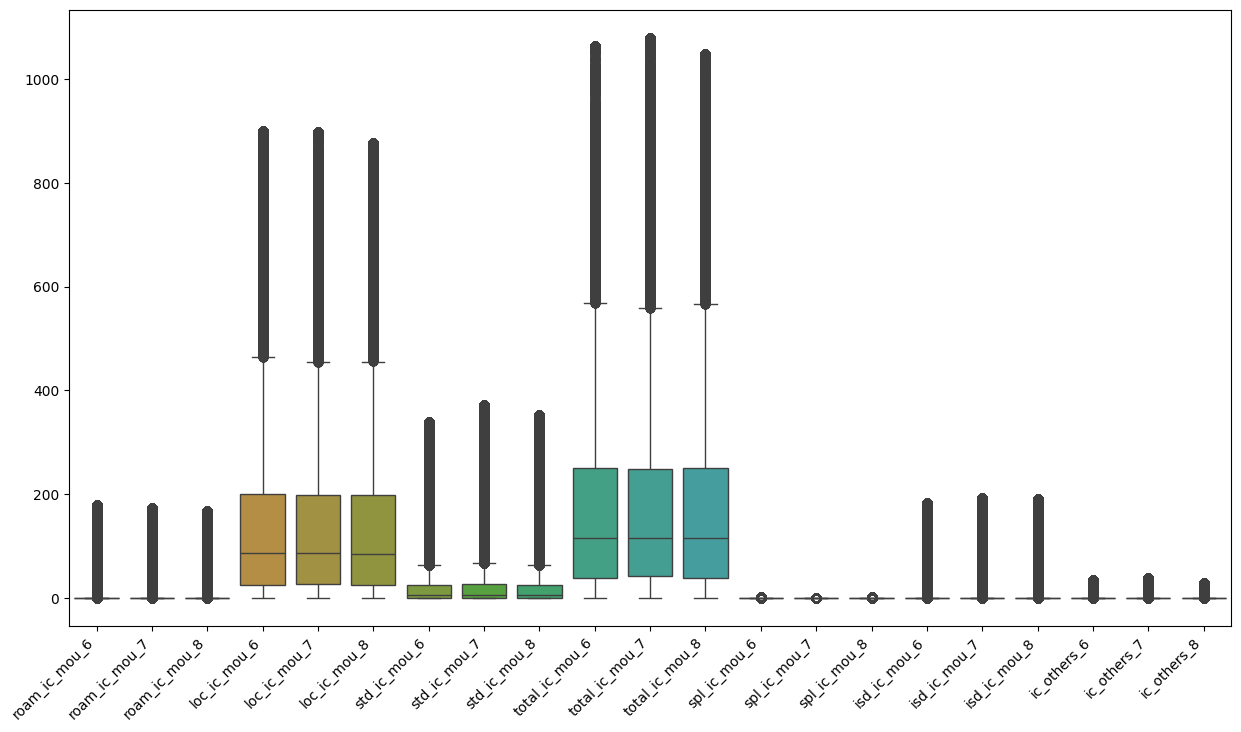

In [ ]:
# Incoming Usage Metrics
columns = [i for i in list(X_train_filtered1.columns) if re.search('ic',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train_filtered1[columns])
plt.show()

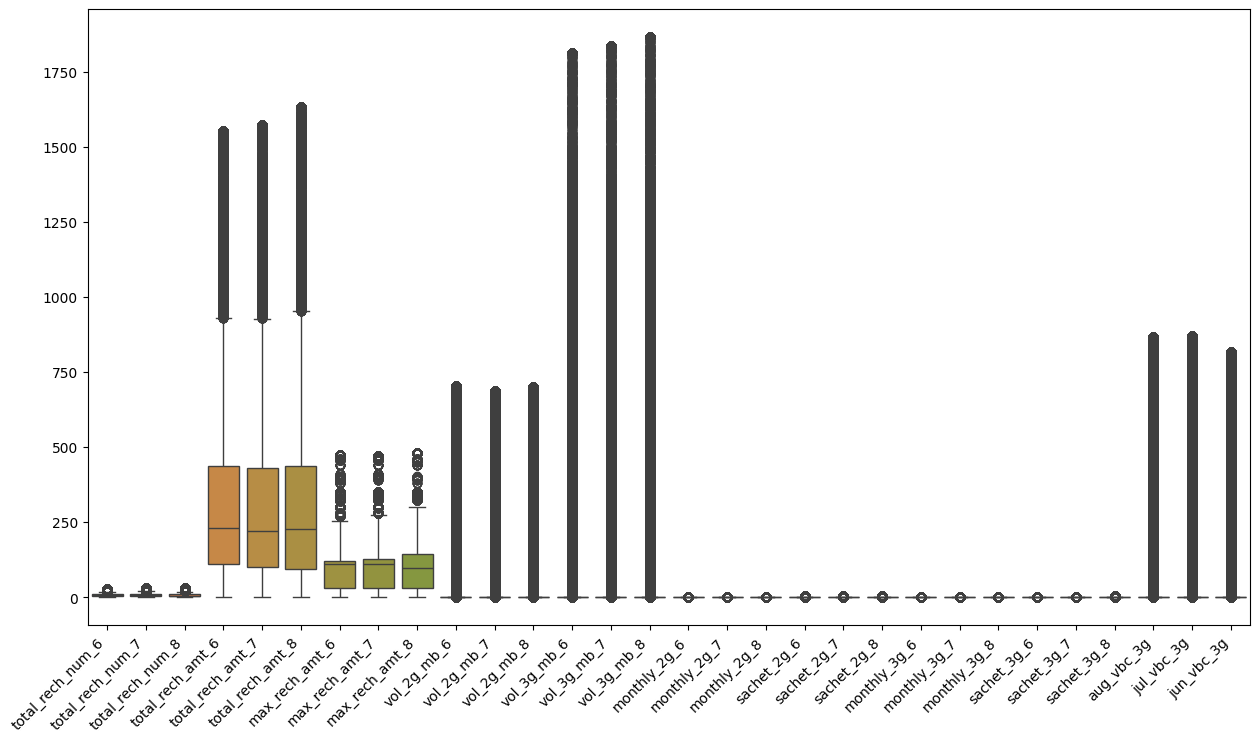

In [ ]:
# Data Usage and Recharge Patterns
columns = [i for i in list(X_train_filtered1.columns) if re.search('2g|3g|rech',i)]
plt.figure(figsize=(15,8))
plt.xticks(rotation=45, ha='right')
sns.boxplot(data = X_train_filtered1[columns])
plt.show()

In [ ]:
X_train_filtered1.columns

Index(['id', 'arpu_6', 'arpu_7', 'arpu_8', 'onnet_mou_6', 'onnet_mou_7',
       'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8',
       'roam_ic_mou_6', 'roam_ic_mou_7', 'roam_ic_mou_8', 'roam_og_mou_6',
       'roam_og_mou_7', 'roam_og_mou_8', 'loc_og_mou_6', 'loc_og_mou_7',
       'loc_og_mou_8', 'std_og_mou_6', 'std_og_mou_7', 'std_og_mou_8',
       'isd_og_mou_6', 'isd_og_mou_7', 'isd_og_mou_8', 'spl_og_mou_6',
       'spl_og_mou_7', 'spl_og_mou_8', 'og_others_6', 'og_others_7',
       'og_others_8', 'total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8',
       'loc_ic_mou_6', 'loc_ic_mou_7', 'loc_ic_mou_8', 'std_ic_mou_6',
       'std_ic_mou_7', 'std_ic_mou_8', 'total_ic_mou_6', 'total_ic_mou_7',
       'total_ic_mou_8', 'spl_ic_mou_6', 'spl_ic_mou_7', 'spl_ic_mou_8',
       'isd_ic_mou_6', 'isd_ic_mou_7', 'isd_ic_mou_8', 'ic_others_6',
       'ic_others_7', 'ic_others_8', 'total_rech_num_6', 'total_rech_num_7',
       'total_rech_num_8', 'total_rech_amt_6', 'total_re

## BIVARIATE ANALYSIS

##### 1. Variance of ARPU significantly drops for users having a Churn Probability of 1

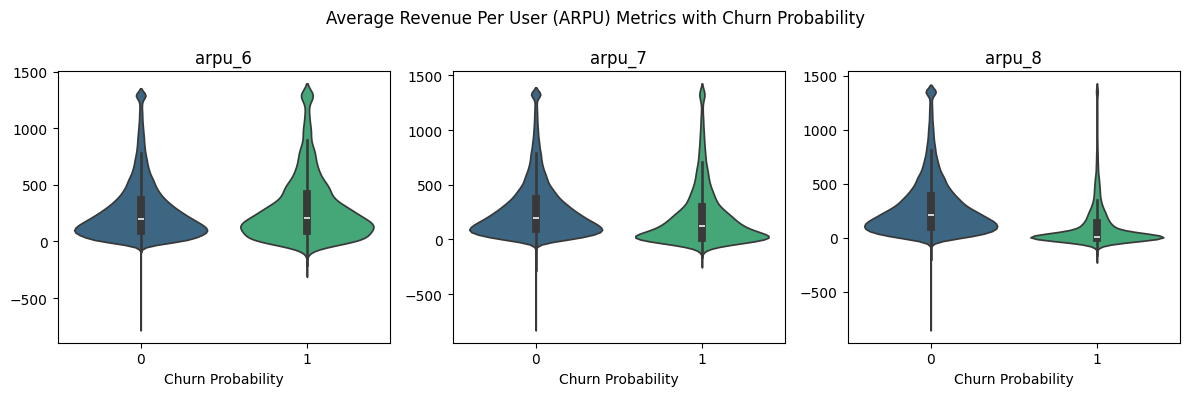

In [ ]:
# Average Revenue Per User
columns = [col for col in X_train_filtered1.columns if re.search('arpu', col)]
plt.figure(figsize=(12, 4))

for i, col in enumerate(columns):
    plt.subplot(1, len(columns), i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train_filtered1[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Average Revenue Per User (ARPU) Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 2. Outgoing Usage Decrease more drastically than Incoming Usage.

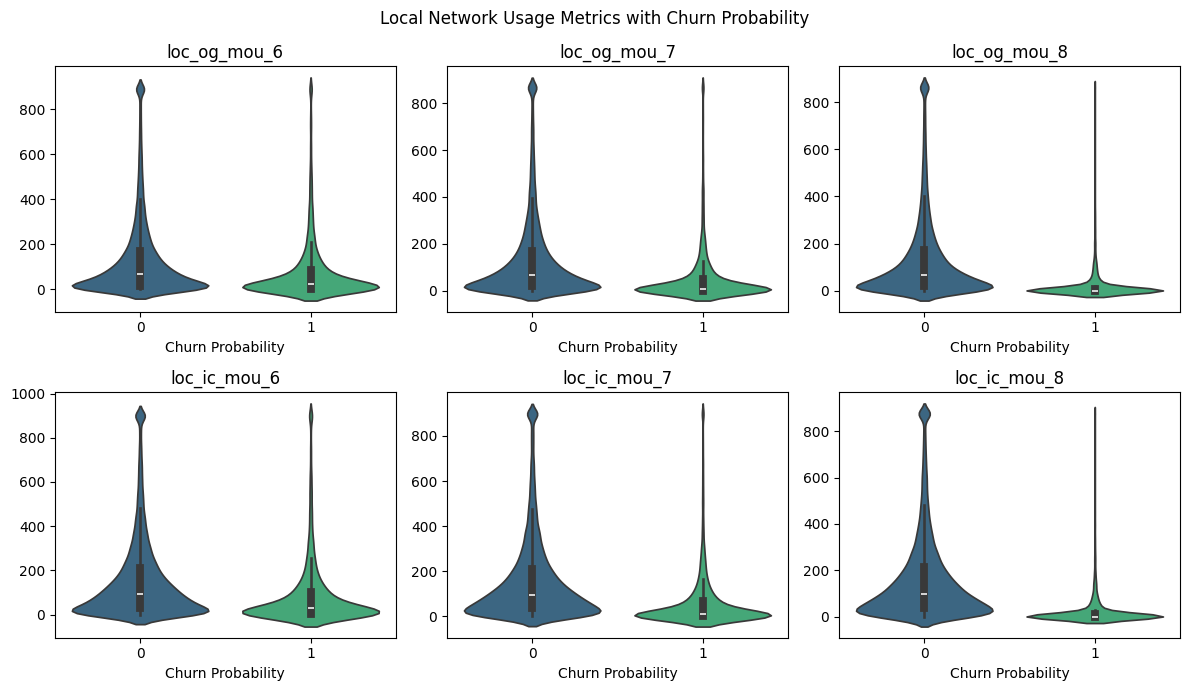

In [ ]:
# Local Network Usage Metrics
columns = [i for i in list(X_train_filtered1.columns) if re.search('loc_ic_mou|loc_og_mou',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train_filtered1[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Local Network Usage Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 3. STD Usage was higher in customers who churned as compared to customers who didn't churn in June and drastically decreased over the months. It appears that the customers who churn usually used the telecom services for STD rather than local.

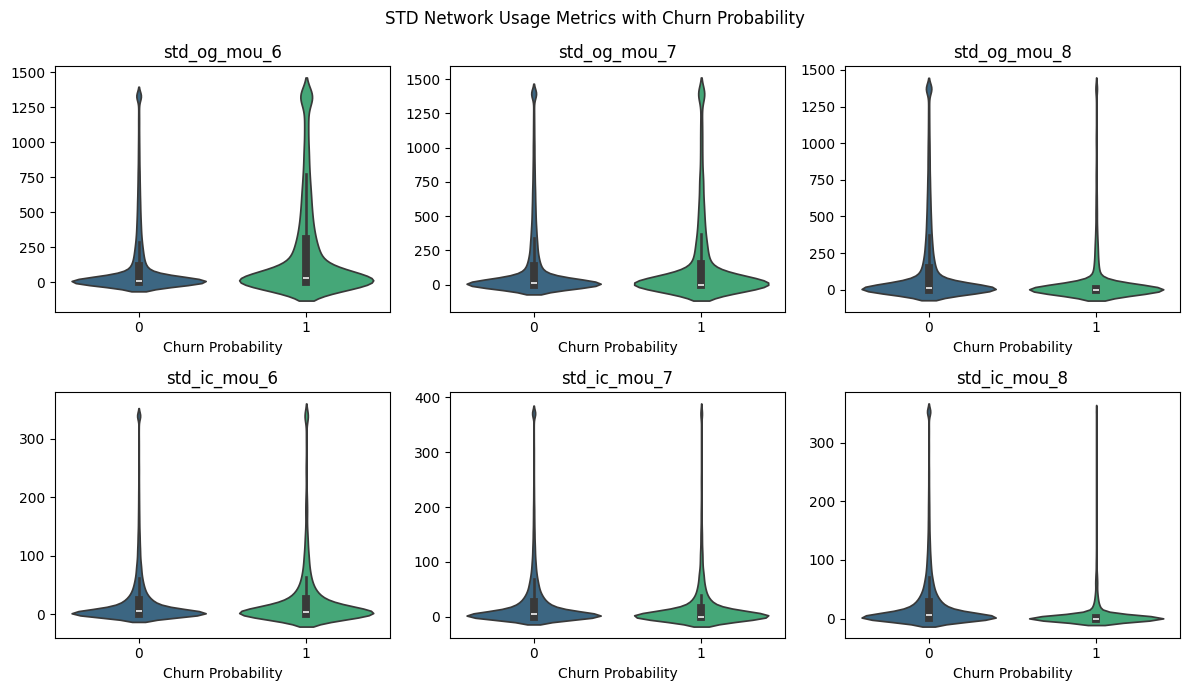

In [ ]:
# STD Network Usage Metrics
columns = [i for i in list(X_train_filtered1.columns) if re.search('std_ic_mou|std_og_mou',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train_filtered1[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('STD Network Usage Metrics with Churn Probability')
plt.tight_layout()
plt.show()

##### 4. Maximum Recharge Amount decreased from 100 to 50  and then to zero over the months.

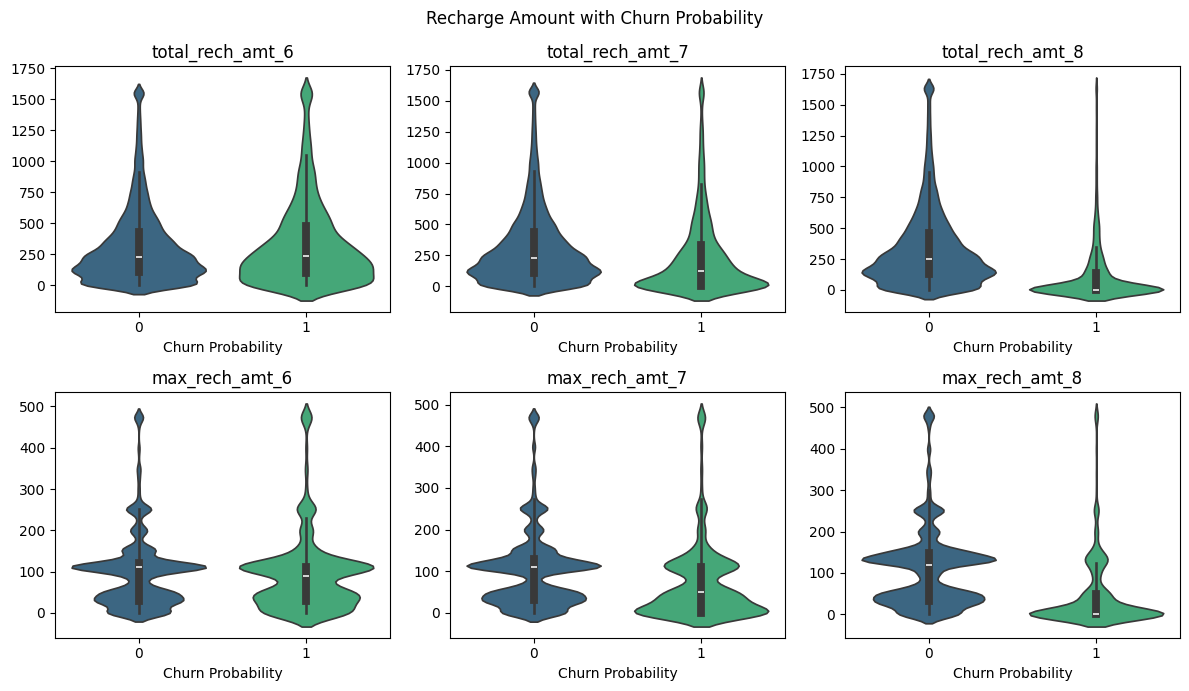

In [ ]:
# Recharge Patterns
columns = [i for i in list(X_train_filtered1.columns) if re.search('rech_amt',i)]
plt.figure(figsize=(12, 7))

for i, col in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    sns.violinplot(x=pd.Series(y_train), y=X_train_filtered1[col], palette="viridis")
    plt.title(f'{col}')
    plt.xlabel('Churn Probability')
    plt.ylabel('')

plt.suptitle('Recharge Amount with Churn Probability')
plt.tight_layout()
plt.show()

### 4.2 Feature scaling

Lets also scale the features by scaling them with Standard scaler (few other alternates are min-max scaling and Z-scaling).

In [ ]:
scale = StandardScaler()
X_train_filtered2 = scale.fit_transform(X_train_filtered1)
X_train_filtered3 = pd.DataFrame(X_train_filtered2)
X_test_scaled = pd.DataFrame(scale.transform(X_test[impute_cols]))
unseen_scaled = pd.DataFrame(scale.transform(unseen[impute_cols]))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- arpu_2g_6
- arpu_2g_7
- arpu_2g_8
- arpu_3g_6
- arpu_3g_7
- ...


<Axes: >

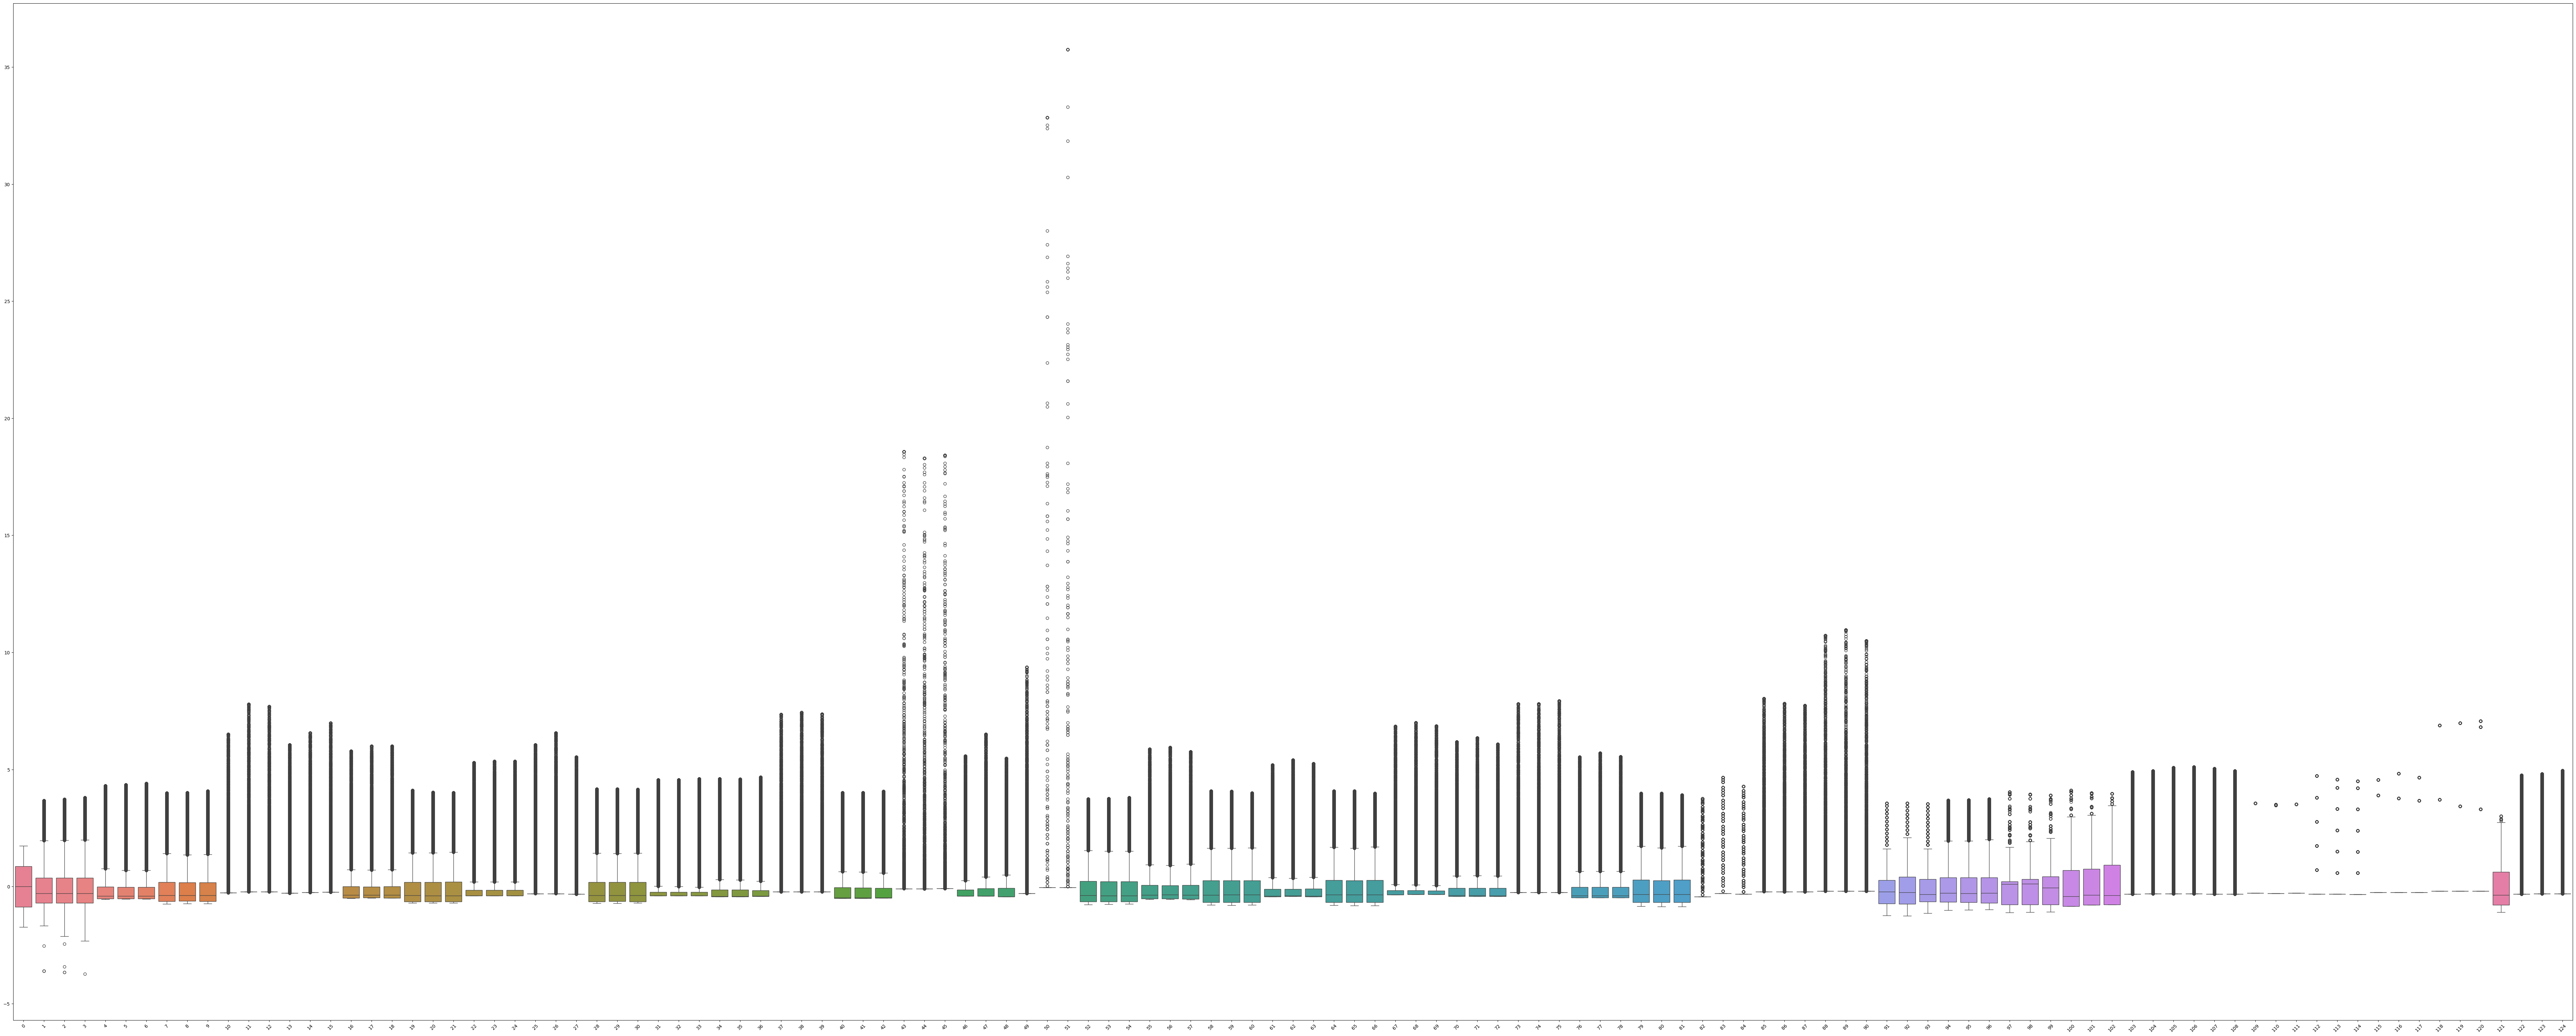

In [ ]:
plt.figure(figsize=(100,40))
plt.xticks(rotation=45)
sns.boxplot(data = pd.DataFrame(X_train_filtered3))

You can perform feature transformations at this stage. 

1. **Positively skewed:** Common transformations of this data include square root, cube root, and log.
2. **Negatively skewed:** Common transformations include square, cube root and logarithmic.

Please read the following link to understand how to perform feature scaling and preprocessing : https://scikit-learn.org/stable/modules/preprocessing.html
 
Lets also plot the correlations for each feature for bivariate analysis.

In [ ]:
""" plt.figure(figsize=(150,50))"""
corr_matrics = X_train_filtered3.corr() 
high_corr = corr_matrics[(corr_matrics > 0.80)|(corr_matrics < -0.80)]
""" sns.heatmap(high_corr) """
high_corr.stack()

id                           id                             1.000000
arpu_8                       arpu_8                         1.000000
                             total_rech_amt_8               0.950479
onnet_mou_8                  onnet_mou_8                    1.000000
                             std_og_t2t_mou_8               0.877089
offnet_mou_8                 offnet_mou_8                   1.000000
                             std_og_t2m_mou_8               0.800164
                             total_og_mou_8                 0.801056
roam_ic_mou_8                roam_ic_mou_8                  1.000000
roam_og_mou_8                roam_og_mou_8                  1.000000
loc_og_t2t_mou_8             loc_og_t2t_mou_8               1.000000
                             good_phase_loc_og_t2t_mou      0.816076
loc_og_t2m_mou_8             loc_og_t2m_mou_8               1.000000
                             loc_og_mou_8                   0.899851
                             good_

<Axes: xlabel='churn_probability', ylabel='Count'>

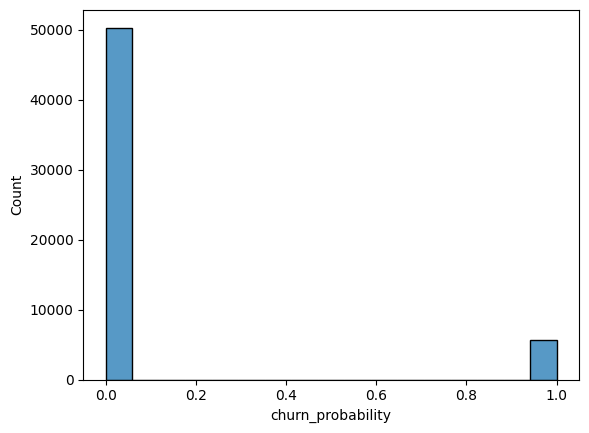

In [ ]:
#Distribution for the churn probability
sns.histplot(y_train)

# 5. Feature engineering and selection

Let's understand feature importances for raw features as well as components to decide top features for modelling.

In [ ]:
X_train_filtered3.columns

Index(['id', 'arpu_6', 'arpu_7', 'arpu_8', 'onnet_mou_6', 'onnet_mou_7',
       'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8',
       ...
       'monthly_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'sachet_3g_6',
       'sachet_3g_7', 'sachet_3g_8', 'aon', 'aug_vbc_3g', 'jul_vbc_3g',
       'jun_vbc_3g'],
      dtype='object', length=125)

In [ ]:
# Ratio of total outgoing amount and age on network (average daily usage)
X_train_filtered3['avg_daily_usage_ratio'] = X_train_filtered3[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / X_train_filtered3['aon']

X_test['avg_daily_usage_ratio'] = X_test[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / X_test['aon']

unseen['avg_daily_usage_ratio'] = unseen[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8']].sum(axis=1) / unseen['aon']

In [ ]:
# Standard deviation of ARPU over the three months
X_train_filtered3['arpu_std_dev'] = X_train_filtered3[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

X_test['arpu_std_dev'] = X_test[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

unseen['arpu_std_dev'] = unseen[['arpu_6', 'arpu_7', 'arpu_8']].std(axis=1)

In [ ]:
columns_to_combine = [i[:-2] for i in list(X_train_filtered1.columns) if re.search('_6|_7', i)]
columns_to_combine = list(set(columns_to_combine))
for col in columns_to_combine:
    X_train_filtered3[f'good_phase_{col}'] = (X_train_filtered3[f'{col}_6'] + X_train_filtered3[f'{col}_7']) / 2
    X_train_filtered3.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
X_train_filtered3['good_phase_vbc_3g'] = (X_train_filtered3['jun_vbc_3g'] + X_train_filtered3['jul_vbc_3g']) / 2
X_train_filtered3.drop(['jun_vbc_3g', 'jul_vbc_3g'], axis=1, inplace=True)

In [ ]:
# Applying the same thing to the test data in order to prevent errors
for col in columns_to_combine:
    X_test[f'good_phase_{col}'] = (X_test[f'{col}_6'] + X_test[f'{col}_7']) / 2
    X_test.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
    
X_test['good_phase_vbc_3g'] = (X_test['jun_vbc_3g'] + X_test['jul_vbc_3g']) / 2

In [ ]:
# Applying the same thing to the unseen data in order to prevent errors
for col in columns_to_combine:
    unseen[f'good_phase_{col}'] = (unseen[f'{col}_6'] + unseen[f'{col}_7']) / 2
    unseen.drop([f'{col}_6', f'{col}_7'], axis=1, inplace=True)
    
unseen['good_phase_vbc_3g'] = (unseen['jun_vbc_3g'] + unseen['jul_vbc_3g']) / 2

In [ ]:
X_train_filtered3.shape

(55999, 86)

##### Features containing `total` have very high correlations with other features that constitute it.

In [ ]:
corr = X_train_filtered3.corr()
corr.loc[:, :] = np.tril(corr, -1)
corr = corr.stack()

In [ ]:
corr[(corr > 0.80) | (corr < -0.80)]

loc_og_mou_8               loc_og_t2m_mou_8             0.899851
std_og_t2t_mou_8           onnet_mou_8                  0.877089
std_og_t2m_mou_8           offnet_mou_8                 0.800164
total_og_mou_8             offnet_mou_8                 0.801056
                           std_og_mou_8                 0.839723
loc_ic_mou_8               loc_ic_t2m_mou_8             0.893842
std_ic_mou_8               std_ic_t2m_mou_8             0.876009
total_ic_mou_8             loc_ic_t2m_mou_8             0.812707
                           loc_ic_mou_8                 0.911083
total_rech_amt_8           arpu_8                       0.950479
good_phase_loc_ic_t2f_mou  loc_ic_t2f_mou_8             0.800231
good_phase_loc_og_t2t_mou  loc_og_t2t_mou_8             0.816076
good_phase_loc_ic_t2t_mou  loc_ic_t2t_mou_8             0.800009
good_phase_loc_ic_mou      loc_ic_mou_8                 0.827514
good_phase_total_rech_amt  good_phase_arpu              0.979318
good_phase_onnet_mou     

In [ ]:
X_train_filtered3.head()

,id,arpu_8,onnet_mou_8,offnet_mou_8,roam_ic_mou_8,roam_og_mou_8,loc_og_t2t_mou_8,loc_og_t2m_mou_8,loc_og_t2f_mou_8,loc_og_t2c_mou_8,loc_og_mou_8,std_og_t2t_mou_8,std_og_t2m_mou_8,std_og_t2f_mou_8,std_og_mou_8,isd_og_mou_8,spl_og_mou_8,og_others_8,total_og_mou_8,loc_ic_t2t_mou_8,loc_ic_t2m_mou_8,loc_ic_t2f_mou_8,loc_ic_mou_8,std_ic_t2t_mou_8,std_ic_t2m_mou_8,std_ic_t2f_mou_8,std_ic_mou_8,total_ic_mou_8,spl_ic_mou_8,isd_ic_mou_8,ic_others_8,total_rech_num_8,total_rech_amt_8,max_rech_amt_8,last_day_rch_amt_8,vol_2g_mb_8,vol_3g_mb_8,monthly_2g_8,sachet_2g_8,monthly_3g_8,sachet_3g_8,aon,aug_vbc_3g,avg_daily_usage_ratio,arpu_std_dev,good_phase_last_day_rch_amt,good_phase_spl_og_mou,good_phase_spl_ic_mou,good_phase_loc_ic_t2f_mou,good_phase_monthly_2g,good_phase_loc_og_t2c_mou,good_phase_loc_og_t2t_mou,good_phase_isd_og_mou,good_phase_total_rech_num,good_phase_std_ic_t2t_mou,good_phase_arpu,good_phase_og_others,good_phase_std_og_t2t_mou,good_phase_sachet_2g,good_phase_total_og_mou,good_phase_loc_ic_t2t_mou,good_phase_std_ic_mou,good_phase_vol_3g_mb,good_phase_vol_2g_mb,good_phase_loc_ic_mou,good_phase_total_rech_amt,good_phase_sachet_3g,good_phase_monthly_3g,good_phase_offnet_mou,good_phase_max_rech_amt,good_phase_roam_ic_mou,good_phase_onnet_mou,good_phase_std_og_t2m_mou,good_phase_isd_ic_mou,good_phase_loc_ic_t2m_mou,good_phase_std_ic_t2f_mou,good_phase_loc_og_t2m_mou,good_phase_std_og_t2f_mou,good_phase_std_ic_t2m_mou,good_phase_ic_others,good_phase_total_ic_mou,good_phase_roam_og_mou,good_phase_loc_og_t2f_mou,good_phase_std_og_mou,good_phase_loc_og_mou,good_phase_vbc_3g
7995,7995,271.332,5.48,298.38,0.0,0.0,5.48,298.38,0.0,0.0,303.86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,303.86,7.81,146.74,2.74,157.31,0.0,0.0,3.68,3.68,160.99,0.0,0.0,0.0,2.0,260.0,130.0,130.000000,0.00,0.000000,0.0000,0.0,0.0,0.0,1990.0,0.0,0.319472,78.440115,110.0,0.0,0.23,4.01,0.000000,0.0,0.4,0.0,4.0,0.0,138.5565,0.0,0.0,0.0,165.945,0.415,3.395,0.000,0.000000,110.335,165.0,0.0,0.0,165.545,110.0,0.0,0.4,0.215,0.0,105.9,3.105,165.33,0.0,0.29,0.03,114.000,0.0,0.0,0.215,165.73,0.0
5186,5186,436.254,487.19,96.64,0.0,0.0,28.39,31.38,0.0,0.0,59.78,458.79,65.26,0.0,524.06,0.0,0.0,0.0,583.84,32.71,38.58,0.3,71.59,15.13,14.39,0.0,29.53,101.13,0.0,0.0,0.0,20.0,510.0,44.0,30.000000,0.00,0.000000,0.0000,0.0,0.0,0.0,2461.0,0.0,0.390134,127.946511,33.0,0.895,0.025,0.0,0.000000,0.0,3.87,0.0,14.0,14.62,245.6995,0.0,157.345,0.0,188.140,7.045,31.92,0.000,0.000000,14.955,288.0,0.0,0.0,31.59,33.0,28.085,207.19,19.465,0.0,7.905,0.0,6.545,0.0,17.295,0.0,46.905,51.55,0.0,176.815,10.42,0.0
15102,15102,321.560,117.96,212.73,7.53,2.58,60.84,172.33,0.0,0.0,233.18,56.98,37.94,0.0,94.93,0.0,0.0,0.0,328.11,24.26,240.48,0.0,264.74,0.0,0.1,0.0,0.1,264.84,0.0,0.0,0.0,15.0,378.0,50.0,30.000000,0.00,0.000000,0.0000,0.0,0.0,0.0,223.0,0.0,2.950762,118.510025,15.0,1.775,0.0,0.0,0.000000,0.0,42.375,0.0,9.0,0.165,165.7060,0.0,12.205,0.0,164.955,15.11,12.13,0.000,0.000000,159.48,189.0,0.0,0.0,108.585,49.0,0.0,54.585,17.885,0.59,144.36,0.0,90.485,0.0,11.965,0.73,172.935,0.0,0.205,30.095,133.075,0.0
62947,62947,646.423,447.53,937.19,0.0,0.0,277.68,536.430347,0.0,0.0,849.63488,169.84,238.46,3.54,411.86,0.0,2.86,0.0,1384.73,197.61,583.554279,0.45,874.472462,37.21,23.53,2.79,63.54,1000.31,0.0,0.0,0.31,5.0,1135.0,398.0,363.727254,0.00,0.000000,0.0000,0.0,0.0,0.0,783.0,0.0,4.307241,118.413267,339.0,0.0,0.0,10.095,0.000000,0.0,215.23,0.04,4.5,25.375,851.4660,0.0,131.83,0.0,993.920,179.21,55.12,0.000,0.000000,641.18,894.5,0.0,0.0,646.85,339.0,0.0,347.06,135.15,2.855,451.86,3.585,488.38701,7.31,26.145,0.0,699.160,0.0,0.0,274.3,719.57,0.0
59278,59278,776.645,558.74,125.49,0.0,0.0,486.940908,124.81,0.68,1.28,684.24,0.0,0.0,0.0,0.0,0.0,1.28,0.0,685.53,22.86,53.03,11.74,87.64,0.0,0.0,0.0,0.0,87.64,0.0,0.0,0.0,10.0,986.0,154.0,130.000000,87.27,1817.629686,0.9837,1.0,0.0,0.0,2242.0,0.0,1.004607,266.857318,0.0,10.37,0.155,35.025,0.982349,10.37,489.965353,0.0,5.0,0.0,318.4805,0.0,0.0,0.0,783.400,28.575,1.99,1048.135,451.844629,1

At this step, you can create a bunch of features based on business understanding, such as 
1. "average % gain of 3g volume from month 6 to 8" - (growth or decline of 3g usage month over month?)
2. "ratio of total outgoing amount and age of user on network" - (average daily usage of a user?)
3. "standard deviation of the total amount paid by user for all services" - (too much variability in charges?)
4. etc..

Another way of finding good features would be to project them into a lower dimensional space using PCA. PCA creates components which are a linear combination of the features. This then allows you to select components which explain the highest amount of variance.

Lets try to project the data onto 2D space and plot. **Note:** you can try TSNE, which is another dimensionality reduction approach as well. Check https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html for moree details.

<Axes: >

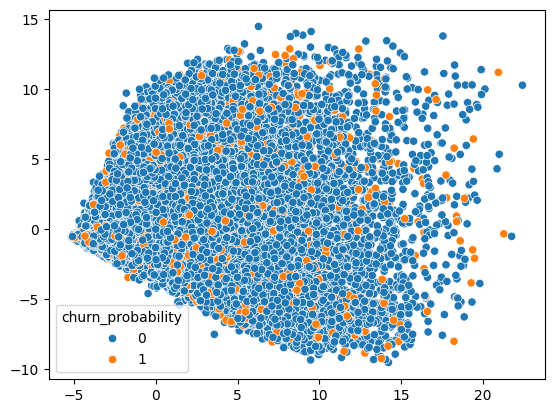

In [ ]:
pca = PCA(random_state=42)
pca_components = pca.fit_transform(X_train_filtered3)
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1], hue=y_train)

<AxesSubplot:>

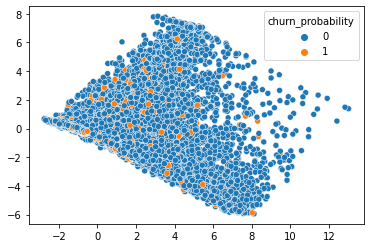

In [ ]:
sns.scatterplot(x=pca_components[:,1], y=pca_components[:,2], hue=y_train)

Let's also check which of the components have high feature importances towards the end goal of churn prediction.

<BarContainer object of 16 artists>

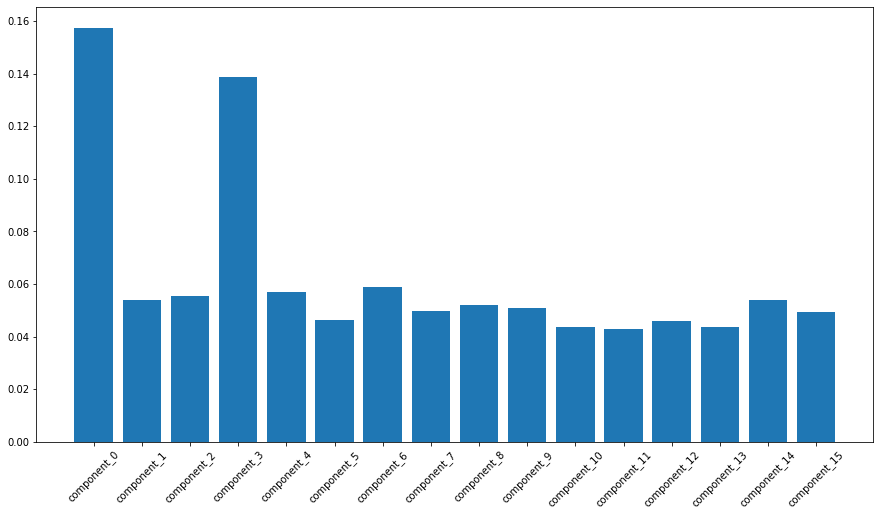

In [ ]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(pca_components, y_train)

feature_importances = pd.DataFrame({'col':['component_'+str(i) for i in range(16)], 
                                    'importance':rf.feature_importances_})

plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
plt.bar(feature_importances['col'], feature_importances['importance'])

# 6. Model building

Let's build a quick model with logistic regression and the first 2 PCA components.

In [ ]:
lr = LogisticRegression(max_iter=1000, tol=0.001, solver='sag')
lr.fit(pca_components[:,:2], y_train)

LogisticRegression(max_iter=1000, solver='sag', tol=0.001)

In [ ]:
lr.score(pca_components[:,:2], y_train)

0.8981053233093448

The model has 89.8% accuracy, but let's build a pipeline to fit and score the model faster.

The steps of this pipeline would be the following, but this is only one type of pipeline -
1. Imputation
2. Scaling
3. PCA
4. Classification model

You can change this pipeline, add addition transformations, change models, use cross validation or even use this pipeline to work with a Gridsearch.

In [ ]:
imp = SimpleImputer(strategy='constant', fill_value=0)
scale = StandardScaler()
pca = PCA(n_components=10)
lr = LogisticRegression(max_iter=1000, tol=0.001)

In [ ]:
pipe = Pipeline(steps = [('imputation',imp),
                         ('scaling',scale),
                         ('pca',pca),
                         ('model',lr)])

In [ ]:
pipe.fit(X_train[new_vars], y_train)

Pipeline(steps=[('imputation',
                 SimpleImputer(fill_value=0, strategy='constant')),
                ('scaling', StandardScaler()), ('pca', PCA(n_components=10)),
                ('model', LogisticRegression(max_iter=1000, tol=0.001))])

In [ ]:
train_score = pipe.score(X_train[new_vars], y_train)
print("Training accuracy:", train_score)

Training accuracy: 0.9001232164860087


In [ ]:
test_score = pipe.score(X_test[new_vars], y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.9


Let's make a confusion matrix to analyze how each class is being predicted by the model.

In [ ]:
confusion_matrix(y_train, pipe.predict(X_train[new_vars]))

array([[50022,   271],
       [ 5322,   384]])

In [ ]:
confusion_matrix(y_test, pipe.predict(X_test[new_vars]))

array([[12507,    67],
       [ 1333,    93]])

We can see a high amount of type 2 error. Due to class imbalance, the model is clearly trying to predict majority of the cases as class 0. Understanding how to handle class imbalance in classification models might be the key to winning this competition :) (hint!)

In [ ]:
precision_score(y_test, pipe.predict(X_test[new_vars]))

0.58125

In [ ]:
recall_score(y_test, pipe.predict(X_test[new_vars]))

0.06521739130434782

# 7. Creating submission file

For submission, we need to make sure that the format is exactly the same as the sample.csv file. It contains 2 columns, id and churn_probability

In [ ]:
sample.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


The submission file should contain churn_probability values that have to be predicted for the unseen data provided (test.csv)

In [ ]:
unseen.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,...,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,...,0,0,0,NaN,NaN,NaN,2533,0.00,0.00,0.00
2,70001,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,329.844,434.884,...,0,0,0,NaN,NaN,NaN,277,525.61,758.41,241.84
3,70002,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,43.550,171.390,...,0,0,0,NaN,NaN,NaN,1244,0.00,0.00,0.00
4,70003,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,306.854,406.289,...,0,0,0,NaN,NaN,NaN,462,0.00,0.00,0.00


Lets first select the columns that we want to work with (or create them, if you have done any feature engineering)

In [ ]:
submission_data = unseen.set_index('id')[new_vars]
submission_data.shape

(30000, 16)

Next, lets create a new column in the unseen dataset called churn_probability and use the model pipeline to predict the probabilities for this data

In [ ]:
unseen['churn_probability'] = pipe.predict(submission_data)
output = unseen[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


Finally, lets create a csv file out of this dataset, ensuring to set index=False to avoid an addition column in the csv.

In [ ]:
output.to_csv('submission_pca_lr_13jul.csv',index=False)

You can now take this file and upload it as a submission on Kaggle.